# ECG Arrhythmia Classifier — Training on Colab

## Cell 1 — Verify GPU

In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')
print('PyTorch version:', torch.__version__)

CUDA available: True
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


## Cell 2 — Install dependencies

In [2]:
!pip install imbalanced-learn wfdb --quiet
print('Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 127.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
Dependencies ins

## Cell 3 — Mount Drive and set paths

In [10]:
from google.colab import drive
import os, sys

drive.mount('/content/drive')

# ── Edit this one line to match your Drive folder name ──────────────────────
PROJECT_DIR = '/content/drive/MyDrive/6600-Project'
# ────────────────────────────────────────────────────────────────────────────

PROCESSED_DIR  = f'{PROJECT_DIR}/Data/processed'
CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
CODE_DIR       = f'{PROJECT_DIR}/notebooks'

# Create checkpoints folder if it doesn't exist yet
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Add src/ to Python path so imports work without installing as a package
sys.path.insert(0, CODE_DIR)

print('Drive mounted.')
print(f'  Project    : {PROJECT_DIR}  exists={os.path.exists(PROJECT_DIR)}')
print(f'  Processed  : {PROCESSED_DIR}  exists={os.path.exists(PROCESSED_DIR)}')
print(f'  Code       : {CODE_DIR}  exists={os.path.exists(CODE_DIR)}')
print(f'  Checkpoints: {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
  Project    : /content/drive/MyDrive/6600-Project  exists=True
  Processed  : /content/drive/MyDrive/6600-Project/Data/processed  exists=True
  Code       : /content/drive/MyDrive/6600-Project/notebooks  exists=True
  Checkpoints: /content/drive/MyDrive/6600-Project/checkpoints


## Cell 4 — Confirm all files are in place

In [12]:
import numpy as np

# Check code files
print('=== Code files ===')
for fname in ['hybrid_cnn_transformer.py', 'dataset.py', 'train.py']:
    path = f'{CODE_DIR}/{fname}'
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {path}')

# Check data splits and print shapes
print('\n=== Data splits ===')
all_present = True
for fname in ['X_train', 'X_val',  'X_test',
              'y_train', 'y_val',  'y_test',
              'meta_train', 'meta_val', 'meta_test']:
    path = f'{PROCESSED_DIR}/{fname}.npy'
    if os.path.exists(path):
        arr = np.load(path)
        print(f'  [OK]      {fname}.npy  {arr.shape}  {arr.dtype}')
    else:
        print(f'  [MISSING] {path}')
        all_present = False

print()
if all_present:
    print('All files found — ready to train.')
else:
    print('WARNING: some files are missing. Expected structure:')
    print(f'  {PROJECT_DIR}/')
    print(f'    Data/processed/   <- .npy files')
    print(f'    src/              <- .py files')

=== Code files ===
  [OK] /content/drive/MyDrive/6600-Project/notebooks/hybrid_cnn_transformer.py
  [OK] /content/drive/MyDrive/6600-Project/notebooks/dataset.py
  [OK] /content/drive/MyDrive/6600-Project/notebooks/train.py

=== Data splits ===
  [OK]      X_train.npy  (70814, 250)  float32
  [OK]      X_val.npy  (15174, 250)  float32
  [OK]      X_test.npy  (15175, 250)  float32
  [OK]      y_train.npy  (70814,)  int64
  [OK]      y_val.npy  (15174,)  int64
  [OK]      y_test.npy  (15175,)  int64
  [OK]      meta_train.npy  (70814, 6)  float32
  [OK]      meta_val.npy  (15174, 6)  float32
  [OK]      meta_test.npy  (15175, 6)  float32

All files found — ready to train.


## Cell 5 — Patch paths and run training
Overrides the two path entries in `train.py`'s CONFIG so they point at
Drive instead of your local machine. Everything else in CONFIG stays as-is.

In [19]:
import importlib
import train
importlib.reload(train)

train.CONFIG['processed_dir']  = PROCESSED_DIR
train.CONFIG['checkpoint_dir'] = CHECKPOINT_DIR

train.main()


  ECG Arrhythmia Classifier — Training
  Device : cuda
  Epochs : 30

Loaded splits:
  Train : X=(70814, 250)  meta=(70814, 6)  y=Counter({0: 63243, 2: 5065, 1: 1945, 3: 561})
  Val   : X=(15174, 250)    meta=(15174, 6)    y=Counter({0: 13552, 2: 1085, 1: 417, 3: 120})
  Test  : X=(15175, 250)   meta=(15175, 6)   y=Counter({0: 13552, 2: 1085, 1: 417, 3: 121})

=== SMOTE Oversampling ===
  Before — Counter({0: 63243, 2: 5065, 1: 1945, 3: 561})
  After  — Counter({0: 63243, 1: 31621, 2: 31621, 3: 31621})
  Added 87,292 synthetic samples

DataLoaders ready:
  Train batches : 4941  (158,106 samples)
  Val   batches : 475   (15,174 samples)
  Test  batches : 475   (15,175 samples)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 228MB/s]
/content/drive/MyDrive/6600-Project/notebooks/hybrid_cnn_transformer.py:255: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Model parameters — total: 6,612,227  trainable: 6,303,567

Class weights: {0: '0.625', 1: '1.250', 2: '1.250', 3: '1.250'}

  Epoch   1  [ 988/4941]  loss=0.6691  lr_cnn=1.00e-05  lr_trans=3.00e-05
  Epoch   1  [1976/4941]  loss=0.2187  lr_cnn=2.00e-05  lr_trans=6.00e-05
  Epoch   1  [2964/4941]  loss=0.2584  lr_cnn=3.00e-05  lr_trans=9.00e-05
  Epoch   1  [3952/4941]  loss=0.2331  lr_cnn=4.00e-05  lr_trans=1.20e-04
  Epoch   1  [4940/4941]  loss=0.2735  lr_cnn=5.00e-05  lr_trans=1.50e-04

Epoch   1/30  train_loss=0.4266  val_loss=0.1405  val_acc=0.7789  val_f1=0.5217  (324.4s)

  ✓ New best val F1=0.5217 — checkpoint saved

  Epoch   2  [ 988/4941]  loss=0.2008  lr_cnn=6.00e-05  lr_trans=1.80e-04
  Epoch   2  [1976/4941]  loss=0.2143  lr_cnn=7.00e-05  lr_trans=2.10e-04
  Epoch   2  [2964/4941]  loss=0.2571  lr_cnn=8.00e-05  lr_trans=2.40e-04
  Epoch   2  [3952/4941]  loss=0.3269  lr_cnn=9.00e-05  lr_trans=2.70e-04
  Epoch   2  [4940/4941]  loss=0.0800  lr_cnn=1.00e-04  lr_trans=3.00e-

## Cell 6 — Plot training curves

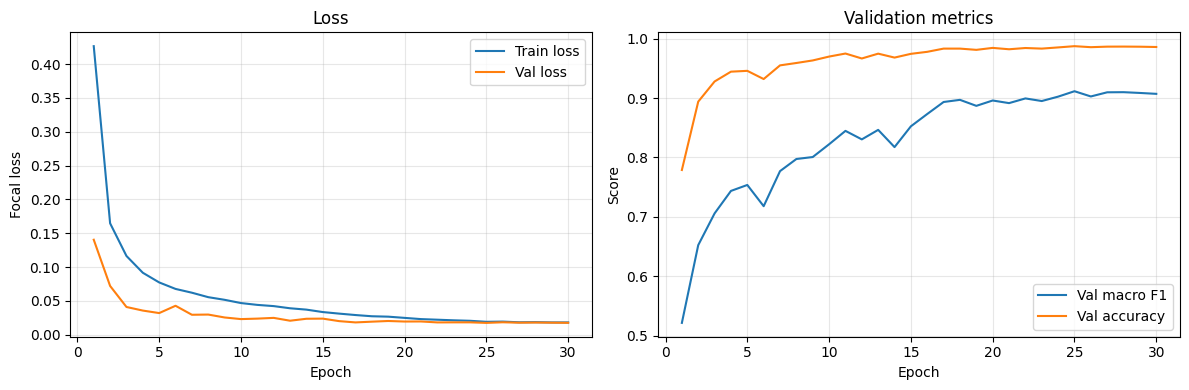

Plot saved to /content/drive/MyDrive/6600-Project/checkpoints/training_curves.png


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

log_path = f'{CHECKPOINT_DIR}/training_log.csv'
df = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df['epoch'], df['train_loss'], label='Train loss')
axes[0].plot(df['epoch'], df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['val_f1'],  label='Val macro F1')
axes[1].plot(df['epoch'], df['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/training_curves.png', dpi=150)
plt.show()
print(f'Plot saved to {CHECKPOINT_DIR}/training_curves.png')

## Cell 7 — Download best checkpoint
Downloads `best_model.pt` to your local machine.
It is also already saved in Drive under `checkpoints/`.

In [21]:
from google.colab import files
files.download(f'{CHECKPOINT_DIR}/best_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>